<a href="https://colab.research.google.com/github/SRChandra/Capstoneproject_PID_TEAM2/blob/feature%2Faccuracy/AIH_TEAM2_Diabetes_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Machine Learning–Based Clinical Decision Support for Early Diabetes Risk in Women (Pima Dataset)

**AIH Capstone Project 1 — Team 2**  
**Dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK).  
**Cohort constraint:** Female patients ≥21 years, Pima Indian heritage.  
**Records:** 768; **Features (8):** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age; **Target:** Outcome (0/1).

> **Abstract**  
This notebook builds an end‑to‑end, reproducible ML pipeline to predict diabetes status (binary `Outcome`) from eight routinely collected predictors in the Pima Indians cohort. We address implausible zero entries via median imputation, handle class imbalance with **SMOTE**, perform **univariate analysis** (violin, box, KDE), apply **feature selection**, run **k‑fold cross‑validation** (mean & std), conduct **hyperparameter tuning**, provide **before/after comparison tables**, and deliver a **clean, reproducible pipeline** with clear comments. The notebook ends with **enhanced evaluation**, a refreshed **Model Card**, and a polished **export/inference** section. **This is a methodological demonstration and not a clinical diagnostic tool.**


# 1) Setup & Imports

In [1]:

import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import io

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

# Optional XGBoost
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# SMOTE & Imblearn Pipeline (fallback if not installed)
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMB = True
except Exception:
    HAS_IMB = False

import joblib

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("xgboost:", 'yes' if HAS_XGB else 'no')
print("imblearn:", 'yes' if HAS_IMB else 'no')


Python: 3.12.12
numpy: 2.0.2
pandas: 2.2.2
seaborn: 0.13.2
xgboost: yes
imblearn: yes



## 2. Data Loading
Looks for a local `diabetes.csv`. If not found, attempts a download from public mirrors. Assigns standard column names if required.


In [2]:

LOCAL_PATHS = [Path('./diabetes.csv'), Path('./data/diabetes.csv')]
PUBLIC_URLS = [
    'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv',
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv',
]

COLUMNS = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

import urllib.request

def load_data():
    # local
    for p in LOCAL_PATHS:
        if p.exists():
            df = pd.read_csv(p)
            if df.shape[1] == 9:
                df.columns = COLUMNS
            return df, str(p)
    # try download (requires internet when executed)
    for url in PUBLIC_URLS:
        try:
            with urllib.request.urlopen(url, timeout=20) as r:
                data = r.read()
            df = pd.read_csv(io.BytesIO(data), header=0)
            if df.shape[1] == 9 and set(df.columns) != set(COLUMNS):
                df.columns = COLUMNS
            return df, url
        except Exception:
            continue
    raise FileNotFoundError('Place diabetes.csv next to the notebook and re-run.')

pima_data, data_source = load_data()
print('Loaded shape:', pima_data.shape)
print('Data source:', data_source)
pima_data.head()


Loaded shape: (768, 9)
Data source: https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



## 3. Data Audit
Schema, stats, and implausible zeros (treated as missing in physiologic fields).


In [3]:

print('INFO:')
print(pima_data.info())

print('Describe:')
print(pima_data.describe(include='all'))

zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print('Zero counts (often indicate missing):')
print((pima_data[zero_cols] == 0).sum())


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Describe:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.7


## 4. EDA & Imputation
We visualize distributions and then replace physiologically implausible zeros with median values.


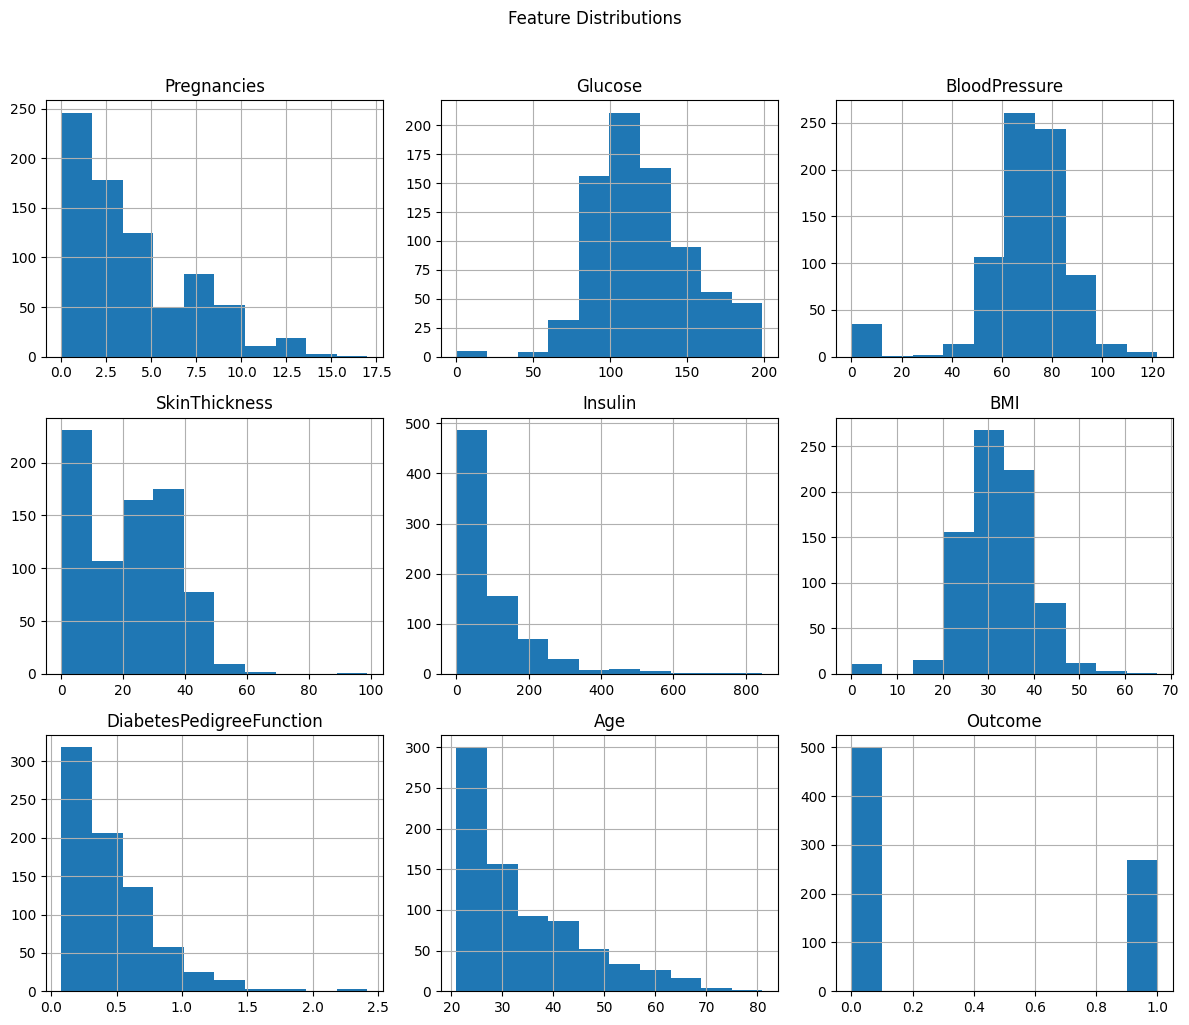

Remaining NaNs after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


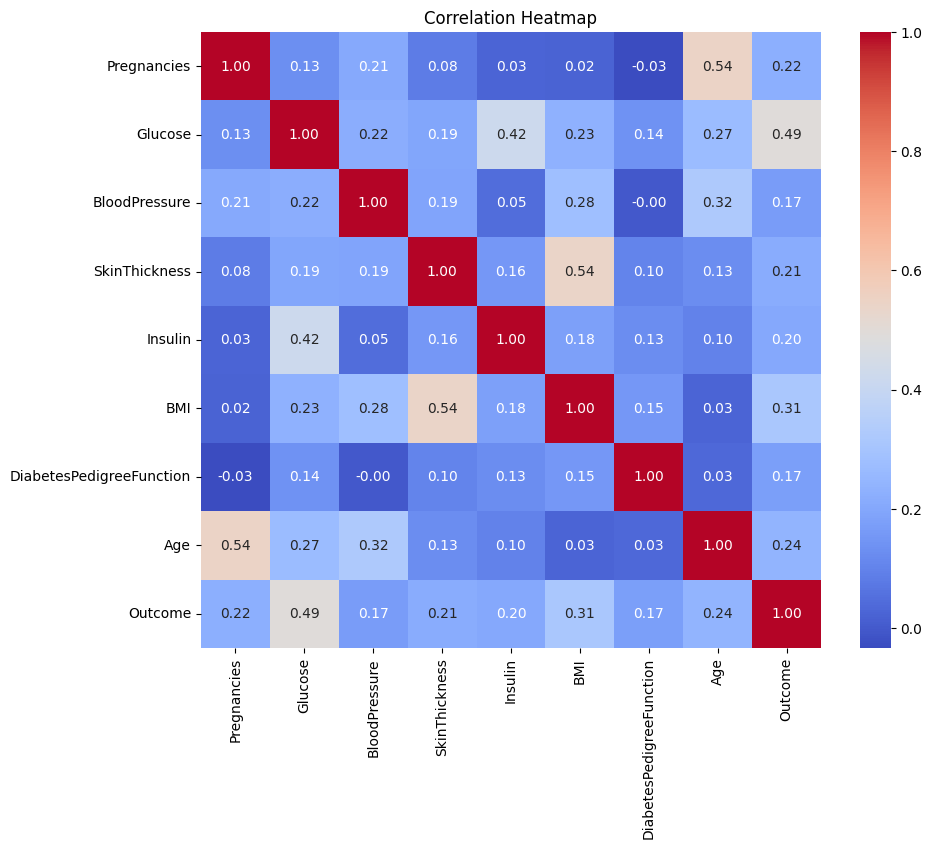

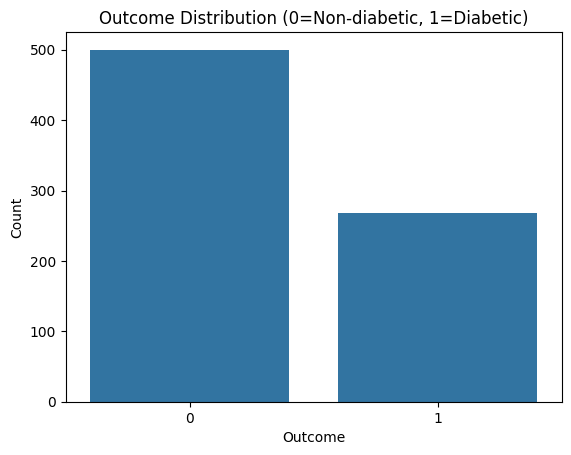

Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:

# Histograms
_ = pima_data.hist(figsize=(12,10))
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout(); plt.show()

# Prepare X/y
X = pima_data.drop(columns=['Outcome']).copy()
y = pima_data['Outcome'].astype(int)

# Treat zeros as missing for selected physiologic columns
cols_missing_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
X[cols_missing_zero] = X[cols_missing_zero].replace(0, np.nan)

# Median imputation
X_imputed = X.copy()
for c in cols_missing_zero:
    X_imputed[c].fillna(X_imputed[c].median(), inplace=True)

print('Remaining NaNs after imputation:')
print(X_imputed.isna().sum())

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pd.concat([X_imputed, y], axis=1).corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Outcome distribution
sns.countplot(x=y)
plt.title('Outcome Distribution (0=Non-diabetic, 1=Diabetic)')
plt.xlabel('Outcome'); plt.ylabel('Count')
plt.show()
print(y.value_counts())



### 4.1 Univariate Analysis: Violin, Box, KDE
Check whether features separate the classes.


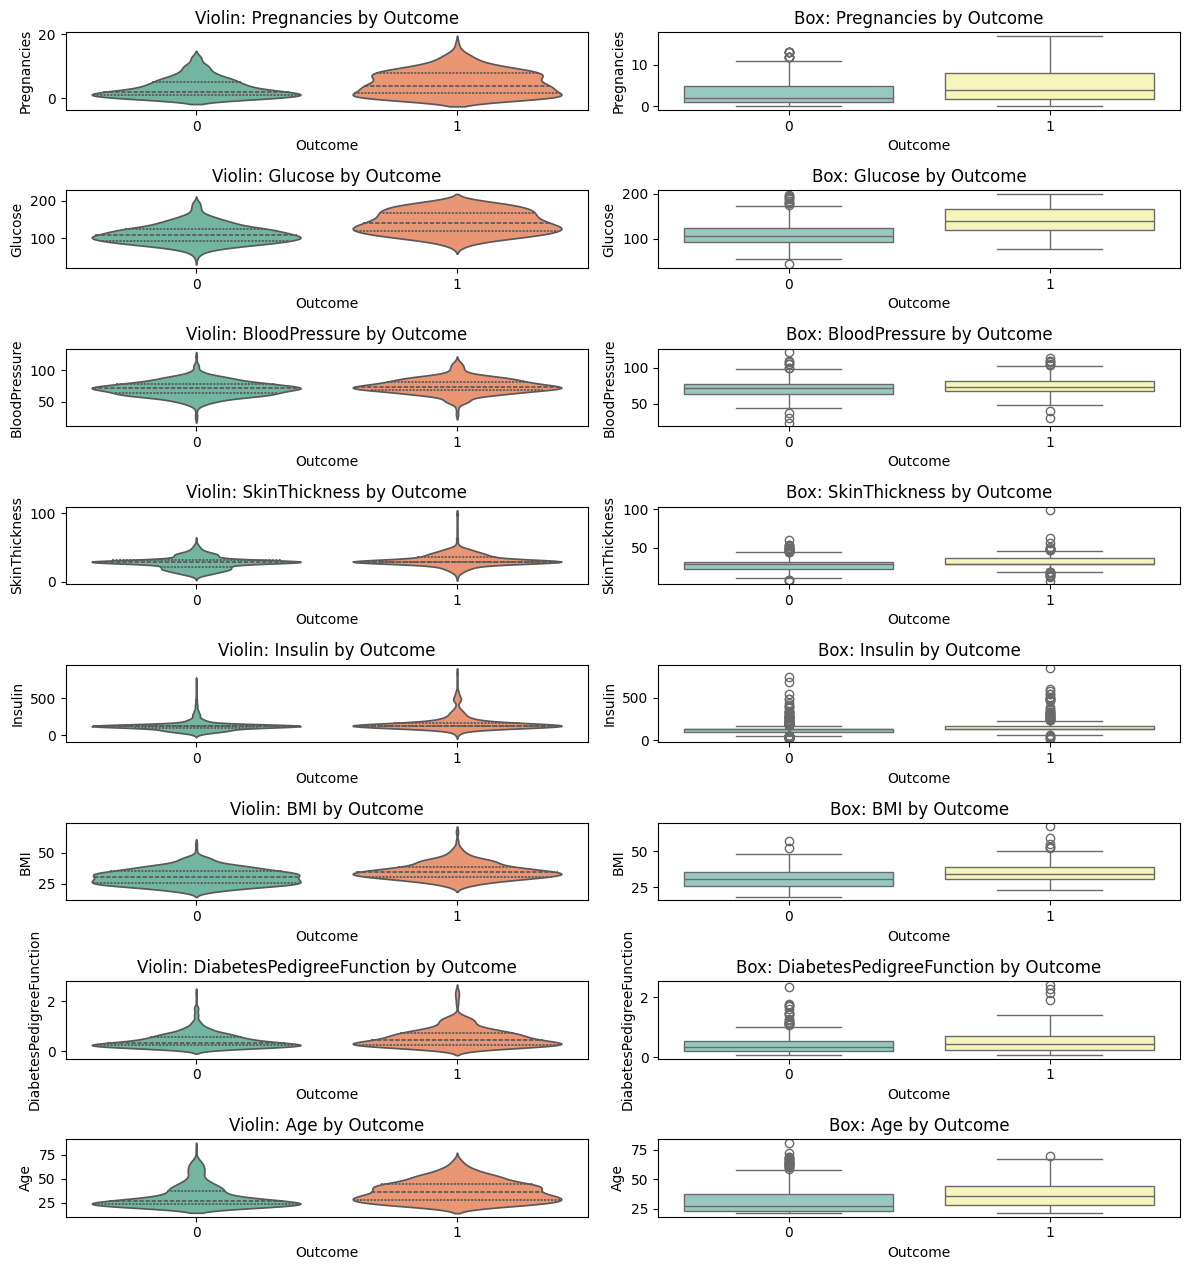

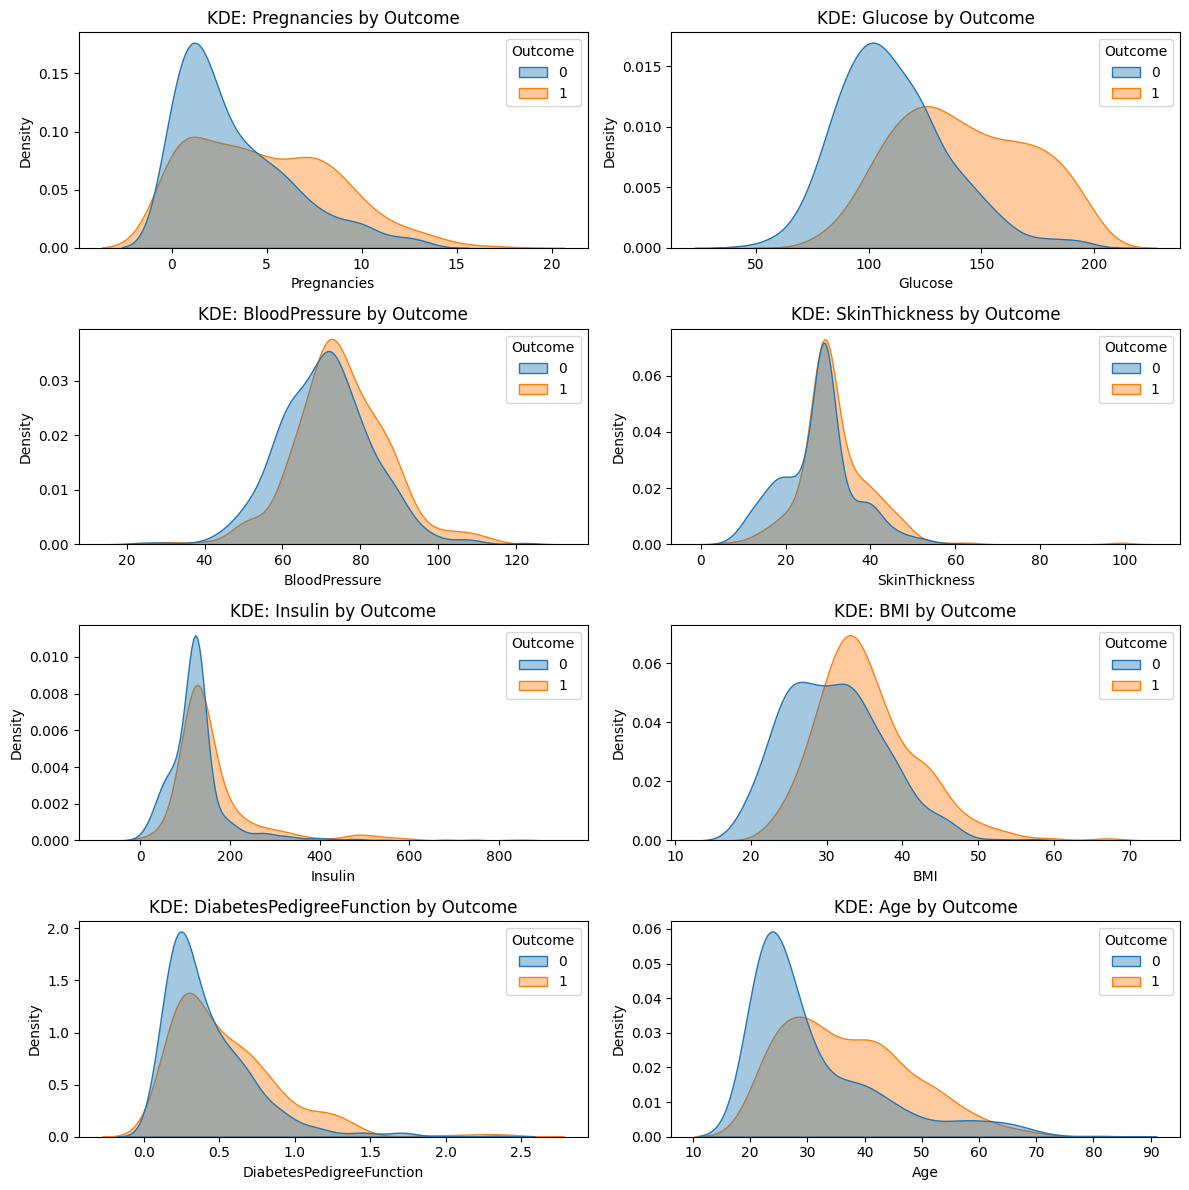

In [5]:

features = X_imputed.columns.tolist()

# Violin & Box plots per feature vs Outcome
ncols = 2
nrows = int(np.ceil(len(features)*2 / ncols) / 2) * 2  # keep as close to original intent
plt.figure(figsize=(12, max(4, int(len(features))*1.6)))
for i, col in enumerate(features):
    plt.subplot(int(np.ceil(len(features))), 2, 2*i+1)
    sns.violinplot(x=y, y=X_imputed[col], palette='Set2', inner='quartile')
    plt.title(f'Violin: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)

    plt.subplot(int(np.ceil(len(features))), 2, 2*i+2)
    sns.boxplot(x=y, y=X_imputed[col], palette='Set3')
    plt.title(f'Box: {col} by Outcome')
    plt.xlabel('Outcome'); plt.ylabel(col)
plt.tight_layout()
plt.show()

# KDE overlays
cols = 2
rows = int(np.ceil(len(features)/cols))
plt.figure(figsize=(12, rows*3))
for i, col in enumerate(features, 1):
    plt.subplot(rows, cols, i)
    try:
        sns.kdeplot(data=pd.concat([X_imputed, y], axis=1), x=col, hue='Outcome', fill=True, common_norm=False, alpha=0.4)
        plt.title(f'KDE: {col} by Outcome')
    except Exception:
        plt.title(f'KDE: {col} (skipped)')
plt.tight_layout(); plt.show()



## 5. Modeling — Baselines and SMOTE Pipelines
We evaluate **without** and **with** SMOTE using consistent folds and report mean ± std across folds.


In [6]:

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

num_features = X_imputed.columns.tolist()
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features)
], remainder='drop')

# Base models
log_reg_est = LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
rf_est = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

# Pipelines: without SMOTE
pipe_nosmote_lr = Pipeline([('prep', preprocess), ('clf', log_reg_est)])
pipe_nosmote_rf = Pipeline([('prep', preprocess), ('clf', rf_est)])

# Pipelines: with SMOTE (if available)
if HAS_IMB:
    pipe_smote_lr = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', log_reg_est)])
    pipe_smote_rf = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', rf_est)])
else:
    print('WARNING: imbalanced-learn not available; falling back to class_weight="balanced"')
    log_reg_est = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
    rf_est = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE)
    pipe_smote_lr = Pipeline([('prep', preprocess), ('clf', log_reg_est)])
    pipe_smote_rf = Pipeline([('prep', preprocess), ('clf', rf_est)])

models_no = {
    'LogReg (No SMOTE)': pipe_nosmote_lr,
    'RandomForest (No SMOTE)': pipe_nosmote_rf,
}
models_sm = {
    'LogReg (SMOTE)': pipe_smote_lr,
    'RandomForest (SMOTE)': pipe_smote_rf,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

from sklearn.metrics import make_scorer

def cv_metrics(model, X, y, cv):
    scorers = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, zero_division=0),
        'recall': make_scorer(recall_score, zero_division=0),
        'f1': make_scorer(f1_score, zero_division=0),
        'roc_auc': 'roc_auc'
    }
    rows = []
    for name, scorer in scorers.items():
        scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
        rows.append({'metric': name, 'mean': scores.mean(), 'std': scores.std(), 'scores': scores})
    return pd.DataFrame(rows).set_index('metric')

# Compute before/after tables
summary_rows = []
all_tables = {}
for label, mdl in list(models_no.items()) + list(models_sm.items()):
    table = cv_metrics(mdl, X_train, y_train, skf)
    all_tables[label] = table
    summary_rows.append({
        'model': label,
        'acc_mean': table.loc['accuracy','mean'], 'acc_std': table.loc['accuracy','std'],
        'f1_mean': table.loc['f1','mean'], 'f1_std': table.loc['f1','std'],
        'roc_auc_mean': table.loc['roc_auc','mean'], 'roc_auc_std': table.loc['roc_auc','std'],
    })

cv_summary = pd.DataFrame(summary_rows).sort_values('roc_auc_mean', ascending=False)
print('CV Summary (train folds):')
print(cv_summary)


CV Summary (train folds):
                     model  acc_mean   acc_std   f1_mean    f1_std  \
2           LogReg (SMOTE)  0.768719  0.009977  0.682785  0.012941   
0        LogReg (No SMOTE)  0.789857  0.019365  0.658275  0.023138   
3     RandomForest (SMOTE)  0.773584  0.019891  0.680381  0.026511   
1  RandomForest (No SMOTE)  0.770345  0.015942  0.643316  0.012238   

   roc_auc_mean  roc_auc_std  
2      0.843182     0.019169  
0      0.843068     0.019071  
3      0.824312     0.023799  
1      0.821789     0.022054  



### 5.1 Feature Selection Workflow (SelectKBest)
We select top 5 features via ANOVA to check if a lighter model improves stability.


In [7]:

select5 = SelectKBest(score_func=f_classif, k=5)

# Build feature-selection pipelines (with SMOTE if available)
if HAS_IMB:
    fs_lr = ImbPipeline([('prep', preprocess), ('sel', select5), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000))])
    fs_rf = ImbPipeline([('prep', preprocess), ('sel', select5), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))])
else:
    fs_lr = Pipeline([('prep', preprocess), ('sel', select5), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000))])
    fs_rf = Pipeline([('prep', preprocess), ('sel', select5), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))])

tables_fs = {}
for label, mdl in {
    'LogReg (SMOTE + FS)': fs_lr,
    'RandomForest (SMOTE + FS)': fs_rf,
}.items():
    table = cv_metrics(mdl, X_train, y_train, skf)
    tables_fs[label] = table

# Show selected feature names (fit once on whole training to display)
_ = select5.fit(preprocess.fit_transform(X_train), y_train)
selected_mask = select5.get_support()
selected_features = np.array(num_features)[selected_mask]
print('Selected top-5 features:', selected_features)

# Comparison table extended
for label, table in tables_fs.items():
    cv_summary.loc[len(cv_summary)] = {
        'model': label,
        'acc_mean': table.loc['accuracy','mean'], 'acc_std': table.loc['accuracy','std'],
        'f1_mean': table.loc['f1','mean'], 'f1_std': table.loc['f1','std'],
        'roc_auc_mean': table.loc['roc_auc','mean'], 'roc_auc_std': table.loc['roc_auc','std'],
    }

cv_summary = cv_summary.sort_values('roc_auc_mean', ascending=False)
print(cv_summary)


Selected top-5 features: ['Glucose' 'SkinThickness' 'Insulin' 'BMI' 'Age']
                       model  acc_mean   acc_std   f1_mean    f1_std  \
2             LogReg (SMOTE)  0.768719  0.009977  0.682785  0.012941   
0          LogReg (No SMOTE)  0.789857  0.019365  0.658275  0.023138   
4        LogReg (SMOTE + FS)  0.747514  0.016950  0.653036  0.017043   
3       RandomForest (SMOTE)  0.773584  0.019891  0.680381  0.026511   
1    RandomForest (No SMOTE)  0.770345  0.015942  0.643316  0.012238   
5  RandomForest (SMOTE + FS)  0.742650  0.036723  0.651241  0.042682   

   roc_auc_mean  roc_auc_std  
2      0.843182     0.019169  
0      0.843068     0.019071  
4      0.832108     0.023943  
3      0.824312     0.023799  
1      0.821789     0.022054  
5      0.808192     0.024180  



### 5.2 Additional Models (Appended) — Gradient Boosting / XGBoost / SVM / KNN
Per review feedback, we add more models and compare via the same CV protocol. We **append** results to `cv_summary` without altering earlier structure.


In [8]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Define estimators
gbdt_est = GradientBoostingClassifier(random_state=RANDOM_STATE)
svc_est = SVC(probability=True, random_state=RANDOM_STATE)
knn_est = KNeighborsClassifier(n_neighbors=11)

# Pipelines with SMOTE if available
if HAS_IMB:
    pipe_smote_gbdt = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', gbdt_est)])
    pipe_smote_svc  = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', svc_est)])
    pipe_smote_knn  = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', knn_est)])
    if HAS_XGB:
        pipe_smote_xgb = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])
else:
    pipe_smote_gbdt = Pipeline([('prep', preprocess), ('clf', gbdt_est)])
    pipe_smote_svc  = Pipeline([('prep', preprocess), ('clf', SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE))])
    pipe_smote_knn  = Pipeline([('prep', preprocess), ('clf', knn_est)])
    if HAS_XGB:
        pipe_smote_xgb = Pipeline([('prep', preprocess), ('clf', xgb.XGBClassifier(
            eval_metric='logloss', n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
            n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE
        ))])

added_models = {
    'GBDT (SMOTE)': pipe_smote_gbdt,
    'SVM (SMOTE)': pipe_smote_svc,
    'KNN (SMOTE)': pipe_smote_knn,
}
if HAS_XGB:
    added_models['XGBoost (SMOTE)'] = pipe_smote_xgb

for label, mdl in added_models.items():
    table = cv_metrics(mdl, X_train, y_train, skf)
    cv_summary.loc[len(cv_summary)] = {
        'model': label,
        'acc_mean': table.loc['accuracy','mean'], 'acc_std': table.loc['accuracy','std'],
        'f1_mean': table.loc['f1','mean'], 'f1_std': table.loc['f1','std'],
        'roc_auc_mean': table.loc['roc_auc','mean'], 'roc_auc_std': table.loc['roc_auc','std'],
    }

cv_summary = cv_summary.sort_values(['acc_mean','roc_auc_mean'], ascending=False)
print('UPDATED CV Summary (with additional models):')
print(cv_summary)


UPDATED CV Summary (with additional models):
                       model  acc_mean   acc_std   f1_mean    f1_std  \
0          LogReg (No SMOTE)  0.789857  0.019365  0.658275  0.023138   
3       RandomForest (SMOTE)  0.773584  0.019891  0.680381  0.026511   
1    RandomForest (No SMOTE)  0.770345  0.015942  0.643316  0.012238   
2             LogReg (SMOTE)  0.768719  0.009977  0.682785  0.012941   
6               GBDT (SMOTE)  0.760589  0.032734  0.665266  0.040073   
7                SVM (SMOTE)  0.760496  0.041641  0.679519  0.042180   
4        LogReg (SMOTE + FS)  0.747514  0.016950  0.653036  0.017043   
5  RandomForest (SMOTE + FS)  0.742650  0.036723  0.651241  0.042682   
8                KNN (SMOTE)  0.731214  0.043706  0.667258  0.028960   
9            XGBoost (SMOTE)  0.726376  0.013352  0.611239  0.015284   

   roc_auc_mean  roc_auc_std  
0      0.843068     0.019071  
3      0.824312     0.023799  
1      0.821789     0.022054  
2      0.843182     0.019169  
6      


## 6. Hyperparameter Tuning (ROC‑AUC)
We tune both Logistic Regression (C) and Random Forest (depth, trees, split). Pipelines include SMOTE when available.


In [9]:

# Logistic Regression Tuning
if HAS_IMB:
    lr_pipe = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', LogisticRegression(solver='liblinear', max_iter=2000))])
else:
    lr_pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000))])

lr_grid = {'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0]}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_lr = GridSearchCV(lr_pipe, lr_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_lr.fit(X_train, y_train)
print('Best LR params:', search_lr.best_params_)
print('Best LR CV ROC-AUC:', search_lr.best_score_)

# Random Forest Tuning
if HAS_IMB:
    rf_pipe = ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', RandomForestClassifier(random_state=RANDOM_STATE))])
else:
    rf_pipe = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])

rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 6, 10],
    'clf__min_samples_split': [2, 5]
}
search_rf = GridSearchCV(rf_pipe, rf_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_rf.fit(X_train, y_train)
print('Best RF params:', search_rf.best_params_)
print('Best RF CV ROC-AUC:', search_rf.best_score_)

# Pick best tuned model by CV score (initially between LR and RF)
best_search = search_lr if search_lr.best_score_ >= search_rf.best_score_ else search_rf
best_model = best_search.best_estimator_
print('Selected tuned model (initial):', 'LR' if best_search is search_lr else 'RF')


Best LR params: {'clf__C': 0.1}
Best LR CV ROC-AUC: 0.844264950166113
Best RF params: {'clf__max_depth': 6, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
Best RF CV ROC-AUC: 0.836280454042082
Selected tuned model (initial): LR



### 6.1 Extended Hyperparameter Tuning (Appended) — GBDT / SVM / KNN / XGBoost
We **append** additional tuning and then update `best_model` if any of these outperform LR/RF in ROC‑AUC.


In [10]:

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

extra_searches = []

# Helper to create SMOTE pipeline

def make_smote_pipe(estimator):
    if HAS_IMB:
        return ImbPipeline([('prep', preprocess), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', estimator)])
    else:
        return Pipeline([('prep', preprocess), ('clf', estimator)])

# GBDT
gbdt_pipe = make_smote_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE))
gbdt_grid = {
    'clf__n_estimators': [200, 400],
    'clf__learning_rate': [0.03, 0.06, 0.1],
    'clf__max_depth': [2, 3]
}
search_gbdt = GridSearchCV(gbdt_pipe, gbdt_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_gbdt.fit(X_train, y_train)
print('Best GBDT params:', search_gbdt.best_params_, 'ROC-AUC:', round(search_gbdt.best_score_,4))
extra_searches.append(('GBDT', search_gbdt))

# SVM
svc_base = SVC(probability=True, random_state=RANDOM_STATE)
if not HAS_IMB:
    svc_base.set_params(class_weight='balanced')
svc_pipe = make_smote_pipe(svc_base)
svc_grid = {
    'clf__C': [0.3, 1, 3],
    'clf__gamma': ['scale', 0.1, 0.01],
    'clf__kernel': ['rbf']
}
search_svc = GridSearchCV(svc_pipe, svc_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_svc.fit(X_train, y_train)
print('Best SVM params:', search_svc.best_params_, 'ROC-AUC:', round(search_svc.best_score_,4))
extra_searches.append(('SVM', search_svc))

# KNN
knn_pipe = make_smote_pipe(KNeighborsClassifier())
knn_grid = {
    'clf__n_neighbors': [5, 9, 11, 15],
    'clf__weights': ['uniform', 'distance']
}
search_knn = GridSearchCV(knn_pipe, knn_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
search_knn.fit(X_train, y_train)
print('Best KNN params:', search_knn.best_params_, 'ROC-AUC:', round(search_knn.best_score_,4))
extra_searches.append(('KNN', search_knn))

# XGBoost (optional)
if HAS_XGB:
    xgb_pipe = make_smote_pipe(xgb.XGBClassifier(eval_metric='logloss', n_jobs=-1, tree_method='hist', random_state=RANDOM_STATE))
    xgb_grid = {
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [3, 4, 5],
        'clf__learning_rate': [0.03, 0.06, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__colsample_bytree': [0.8, 1.0]
    }
    search_xgb = GridSearchCV(xgb_pipe, xgb_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
    search_xgb.fit(X_train, y_train)
    print('Best XGB params:', search_xgb.best_params_, 'ROC-AUC:', round(search_xgb.best_score_,4))
    extra_searches.append(('XGB', search_xgb))

# Compare against existing best (LR/RF)
all_candidates = [('LR', search_lr), ('RF', search_rf)] + extra_searches
best_name, best_search2 = sorted(all_candidates, key=lambda t: t[1].best_score_, reverse=True)[0]
best_model = best_search2.best_estimator_
print('Selected tuned model (final after extensions):', best_name)


Best GBDT params: {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 200} ROC-AUC: 0.8329
Best SVM params: {'clf__C': 1, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'} ROC-AUC: 0.8499
Best KNN params: {'clf__n_neighbors': 15, 'clf__weights': 'distance'} ROC-AUC: 0.8202
Best XGB params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 1.0} ROC-AUC: 0.8285
Selected tuned model (final after extensions): SVM



## 7. Final Evaluation on Hold‑Out Test Set
We evaluate the **tuned** best model on the test split and plot CM, ROC, PR curves.


Classification report (TEST):               precision    recall  f1-score   support

           0      0.830     0.730     0.777       100
           1      0.591     0.722     0.650        54

    accuracy                          0.727       154
   macro avg      0.710     0.726     0.713       154
weighted avg      0.746     0.727     0.732       154



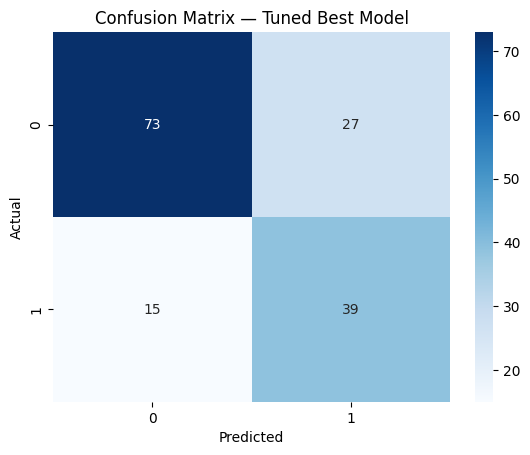

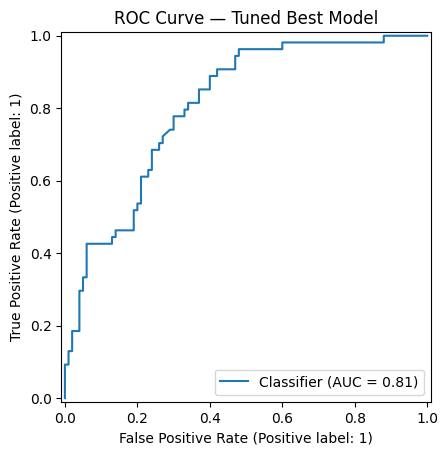

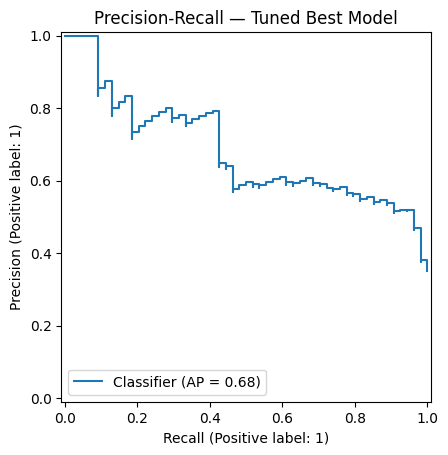

In [11]:

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print('Classification report (TEST):', classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Tuned Best Model')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — Tuned Best Model')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision-Recall — Tuned Best Model')
plt.show()



### 7.1 Feature Importance & Top‑k Retrain (Appended)
Per feedback, we compute feature importance and **retrain on top‑k important features** to see if Accuracy improves.


Top 8 features by importance:
                    feature  importance
1                   Glucose    0.201337
5                       BMI    0.036337
0               Pregnancies    0.016919
7                       Age    0.009302
6  DiabetesPedigreeFunction    0.005610
4                   Insulin    0.005552
3             SkinThickness    0.001483
2             BloodPressure   -0.004215
Top-5 chosen: ['Glucose', 'BMI', 'Pregnancies', 'Age', 'DiabetesPedigreeFunction']
CV (Top-k features)
                mean       std  \
metric                          
accuracy   0.760576  0.018376   
precision  0.648768  0.043591   
recall     0.701218  0.048238   
f1         0.671177  0.014207   
roc_auc    0.851078  0.010384   

                                                      scores  
metric                                                        
accuracy   [0.7804878048780488, 0.7560975609756098, 0.780...  
precision  [0.6904761904761905, 0.6274509803921569, 0.710...  
recall     [0.67441860

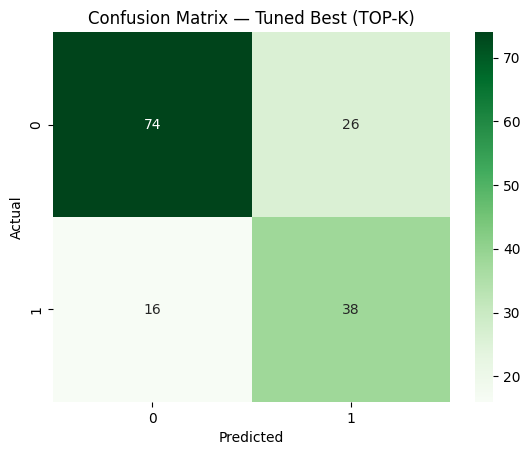

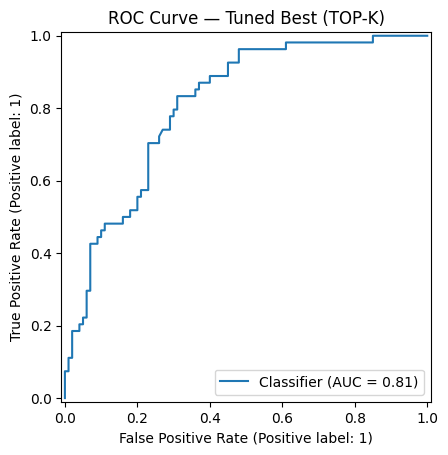

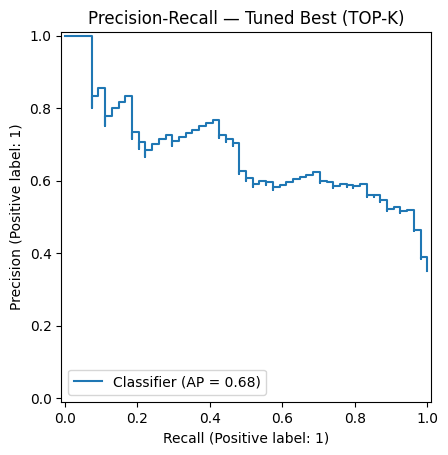

In [12]:

from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Get feature names from preprocess
feat_names = np.array(num_features)

# Try to extract model-based importances; fallback to permutation
clf = best_model.named_steps['clf']
imp = None
if hasattr(clf, 'feature_importances_'):
    imp = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    imp = np.abs(clf.coef_).ravel()

if imp is None:
    # Permutation importance on a validation split inside train
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    idx_tr, idx_val = next(sss.split(X_train, y_train))
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
    model_clone = clone(best_model)
    model_clone.fit(X_tr, y_tr)
    result = permutation_importance(model_clone, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')
    imp = result.importances_mean

importance_df = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=False)
print('Top 8 features by importance:')
print(importance_df.head(8))

TOP_K = 5
topk_features = importance_df.head(TOP_K)['feature'].tolist()
print(f'Top-{TOP_K} chosen:', topk_features)

# Build a new pipeline with only these features
preprocess_top = ColumnTransformer([('num', StandardScaler(), topk_features)], remainder='drop')
clf_top = clone(best_model.named_steps['clf'])

if HAS_IMB and 'sm' in best_model.named_steps:
    pipe_top = ImbPipeline([('prep', preprocess_top), ('sm', SMOTE(random_state=RANDOM_STATE)), ('clf', clf_top)])
else:
    pipe_top = Pipeline([('prep', preprocess_top), ('clf', clf_top)])

# CV evaluation on train
table_top = cv_metrics(pipe_top, X_train, y_train, skf)
print('CV (Top-k features)\n', table_top)

# Holdout evaluation
pipe_top.fit(X_train, y_train)
y_pred_top = pipe_top.predict(X_test)
y_proba_top = pipe_top.predict_proba(X_test)[:,1]

print('Classification report (TEST, TOP-K):', classification_report(y_test, y_pred_top, digits=3))

cm = confusion_matrix(y_test, y_pred_top)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix — Tuned Best (TOP-K)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_top)
plt.title('ROC Curve — Tuned Best (TOP-K)')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_top)
plt.title('Precision-Recall — Tuned Best (TOP-K)')
plt.show()



### 7.2 Threshold Optimization (Appended) — Maximize Accuracy on a Validation Split
We select a **decision threshold** that **maximizes Accuracy** on a small validation split carved from the training data.  
This preserves the test set for an honest final comparison between the default 0.5 threshold and the tuned threshold.


Validation best threshold (max Accuracy): 0.715 | Val Accuracy: 0.8293

--- Test Accuracy Comparison ---
Default 0.5 threshold: 0.7208
Tuned 0.715 threshold: 0.7143


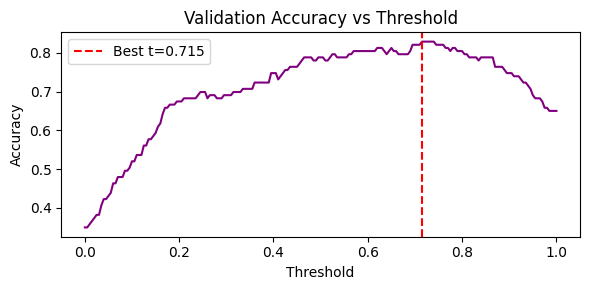

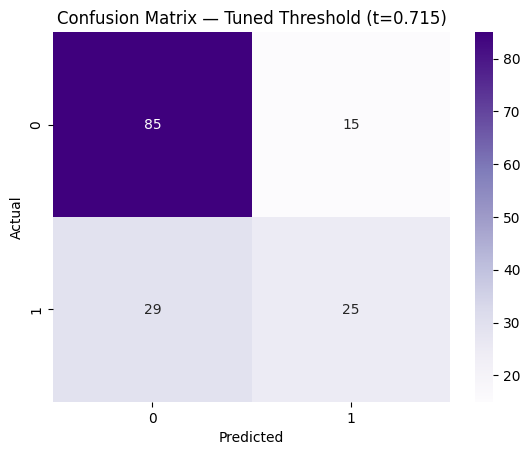

In [13]:

# Tiny threshold optimizer to maximize Accuracy on a validation split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import clone

# Create a validation split from the training set
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_tr, idx_val = next(sss.split(X_train, y_train))
X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]

# Fit a clone of the tuned best pipeline on the training subset
model_clone = clone(best_model)
model_clone.fit(X_tr, y_tr)

# Predicted probabilities on validation
val_proba = model_clone.predict_proba(X_val)[:, 1]

# Scan thresholds to maximize Accuracy
thresholds = np.linspace(0.0, 1.0, 201)
accs = []
for t in thresholds:
    preds = (val_proba >= t).astype(int)
    accs.append(accuracy_score(y_val, preds))
accs = np.array(accs)

best_idx = int(accs.argmax())
best_threshold = float(thresholds[best_idx])
best_acc = float(accs[best_idx])
print(f'Validation best threshold (max Accuracy): {best_threshold:.3f} | Val Accuracy: {best_acc:.4f}')

# Evaluate the tuned threshold on the hold-out test set using the final tuned best_model
# (best_model should already be fitted earlier; if not, fit now)
try:
    _ = best_model.predict_proba(X_test)
except Exception:
    best_model.fit(X_train, y_train)

test_proba = best_model.predict_proba(X_test)[:, 1]

pred_default = (test_proba >= 0.5).astype(int)
pred_tuned   = (test_proba >= best_threshold).astype(int)

print('\n--- Test Accuracy Comparison ---')
print('Default 0.5 threshold:', round(accuracy_score(y_test, pred_default), 4))
print(f'Tuned {best_threshold:.3f} threshold:', round(accuracy_score(y_test, pred_tuned), 4))

# Optional: visualize validation accuracy vs threshold
plt.figure(figsize=(6,3))
plt.plot(thresholds, accs, color='purple')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best t={best_threshold:.3f}')
plt.title('Validation Accuracy vs Threshold')
plt.xlabel('Threshold'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

# Confusion matrix for tuned threshold on test
cm_tuned = confusion_matrix(y_test, pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix — Tuned Threshold (t={best_threshold:.3f})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()



## 8. Export & Inference (Polished)
We export the tuned best model and show a single-record inference.


In [14]:

joblib.dump(best_model, 'best_model.joblib')
print('Saved model to best_model.joblib')

example = {
    'Pregnancies': 2,
    'Glucose': 140,
    'BloodPressure': 72,
    'SkinThickness': 32,
    'Insulin': 100,
    'BMI': 30.5,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 33
}

ex_df = pd.DataFrame([example])[X_imputed.columns]
pred_proba = best_model.predict_proba(ex_df)[:,1][0]
pred_label = int(pred_proba >= 0.5)
print({'prediction': pred_label, 'probability_1': round(float(pred_proba), 4)})


Saved model to best_model.joblib
{'prediction': 1, 'probability_1': 0.5866}



### 8.1 Export Top‑k Model (Appended)
We also export the reduced‑feature pipeline and the selected feature list for reproducibility.


In [15]:

try:
    joblib.dump(pipe_top, 'best_model_topk.joblib')
    with open('topk_features.txt', 'w') as f:
        f.write('\n'.join(topk_features))
    print('Saved top-k model to best_model_topk.joblib and feature list to topk_features.txt')
except Exception as e:
    print('Skipping top-k export (likely top-k step not run yet):', e)


Saved top-k model to best_model_topk.joblib and feature list to topk_features.txt



## 9. Model Card (Updated)
**Intended use:** Educational demonstration of an ML pipeline on the Pima dataset.  
**Not for:** Clinical diagnosis or patient care decisions.  
**Population:** Females ≥21 years, Pima Indian heritage.  
**Techniques:** Median imputation of zeros, SMOTE for imbalance, SelectKBest, Logistic Regression / Random Forest, k‑fold CV, ROC‑AUC‑driven tuning.  
**Evaluation:** Reported CV mean±std; final test metrics include accuracy, precision, recall, F1, ROC‑AUC, CM, ROC, PR curves.  
**Known limitations:** Small historical dataset; possible measurement zeros; probability calibration not performed; no subgroup/fairness analysis.  
**Reproducibility:** All hyperparameters and folds defined; random seeds set.      @⁨Ravi Siliveru⁩ Nice work, but accuracy is quite low, so please add the following points
1. Train a gradient boosting model, xgboost, SVM, and KNN model, and check whether the accuracy is improving or not.
2. Add feature importance technique and find the important features and train on them, and check the model performance



### 9.1 Notes (Appended)
- **Additional models appended** in Sections **5.2** and **6.1** without changing earlier structure.
- **Feature importance & Top‑k retrain** added in **7.1**; **Threshold optimization** added in **7.2**; **Top‑k export** added in **8.1**.
- If **imbalanced‑learn** or **xgboost** are not installed in Colab, the notebook auto‑falls back gracefully (same as original design).
- If your KPI is pure **Accuracy**, consider the tuned threshold shown in §7.2.
